In [ ]:
%pip install --quiet datasets transformers peft pandas matplotlib evaluate jiwer

### Evaluation Results

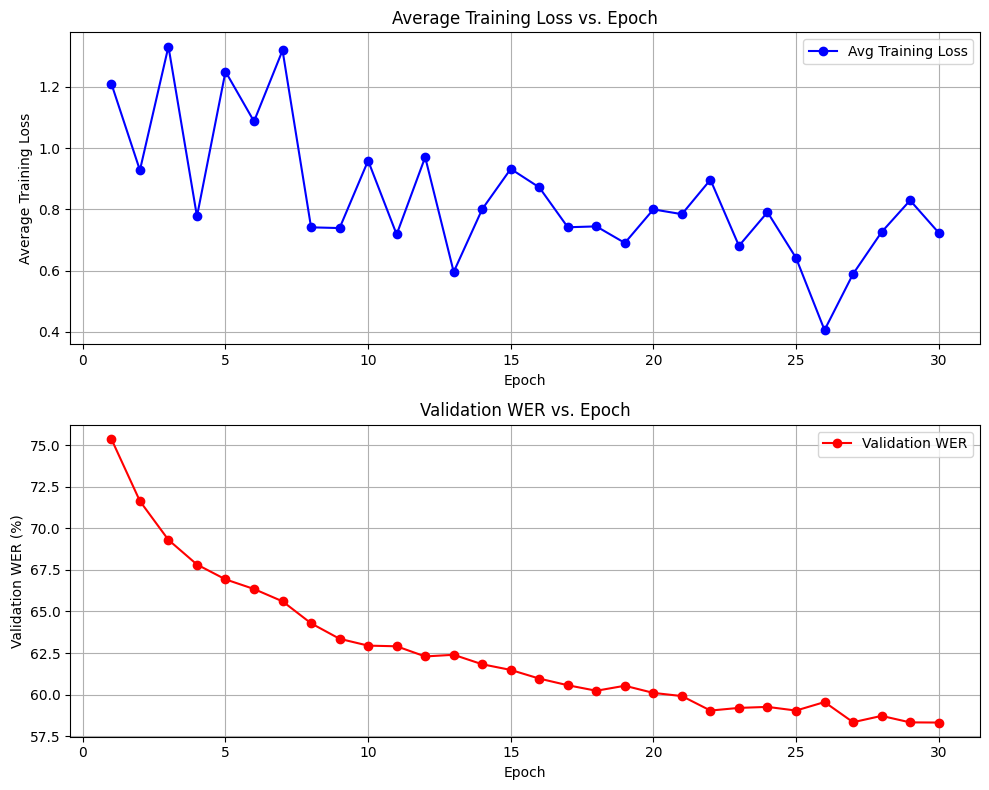

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv('training_metrics_resumed.csv')

epochs = data['epoch']
avg_training_loss = data['avg_training_loss']
validation_wer = data['validation_wer']

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

ax1.plot(epochs, avg_training_loss, marker='o', linestyle='-', color='b', label='Avg Training Loss')
ax1.set_title('Average Training Loss vs. Epoch')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Average Training Loss')
ax1.grid(True)
ax1.legend()

ax2.plot(epochs, validation_wer, marker='o', linestyle='-', color='r', label='Validation WER')
ax2.set_title('Validation WER vs. Epoch')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Validation WER (%)')
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.savefig('training_metrics.png')


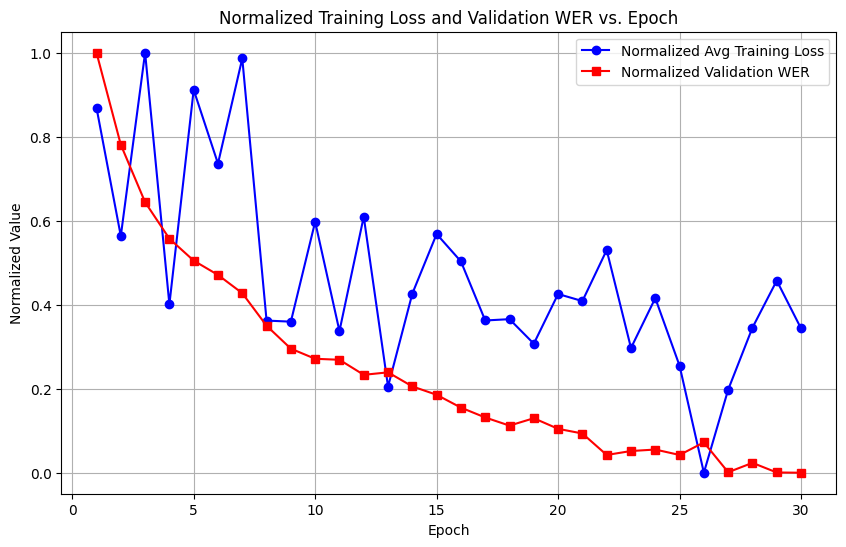

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv('training_metrics_resumed.csv')

epochs = data['epoch']
avg_training_loss = data['avg_training_loss']
validation_wer = data['validation_wer']

loss_normalized = (avg_training_loss - avg_training_loss.min()) / (avg_training_loss.max() - avg_training_loss.min())
wer_normalized = (validation_wer - validation_wer.min()) / (validation_wer.max() - validation_wer.min())

plt.figure(figsize=(10, 6))
plt.plot(epochs, loss_normalized, marker='o', linestyle='-', color='b', label='Normalized Avg Training Loss')
plt.plot(epochs, wer_normalized, marker='s', linestyle='-', color='r', label='Normalized Validation WER')
plt.title('Normalized Training Loss and Validation WER vs. Epoch')
plt.xlabel('Epoch')
plt.ylabel('Normalized Value')
plt.grid(True)
plt.legend()

plt.savefig('training_metrics_normalized.png')

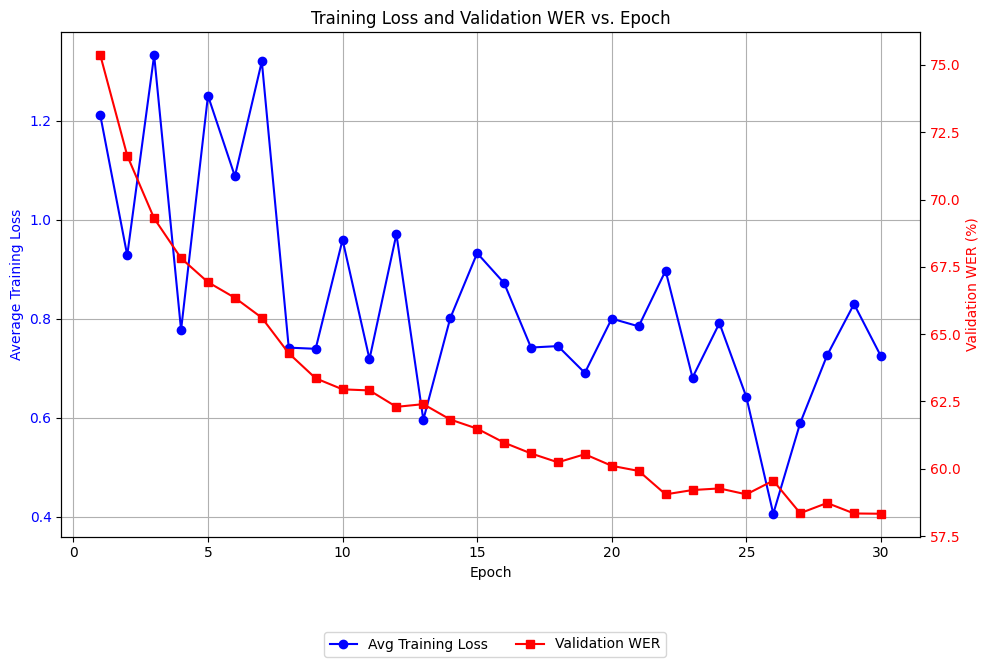

: 

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv('training_metrics_resumed.csv')

epochs = data['epoch']
avg_training_loss = data['avg_training_loss']
validation_wer = data['validation_wer']

fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.plot(epochs, avg_training_loss, marker='o', linestyle='-', color='b', label='Avg Training Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Average Training Loss', color='b')
ax1.tick_params(axis='y', labelcolor='b')
ax1.grid(True)

ax2 = ax1.twinx()
ax2.plot(epochs, validation_wer, marker='s', linestyle='-', color='r', label='Validation WER')
ax2.set_ylabel('Validation WER (%)', color='r')
ax2.tick_params(axis='y', labelcolor='r')

plt.title('Training Loss and Validation WER vs. Epoch')
fig.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=2)

plt.tight_layout()

plt.savefig('training_metrics_non_normalized.png')

- **Training Loss:** The ``training loss`` shows a general downward trend, which is expected as the model learns over time. However, the curve is quite noisy — significant oscillations are visible, particularly during the first 15 epochs. This could be due to small batch sizes, noisy data and/or high learning rate or insufficient regularization. Despite all of that, the general trend is improving, indicating that the model is successfully minimizing the loss function.

- **Word Error Rate (WER):** The ``Validation Word Error Rate (WER)`` consistently decreases in a much smoother fashion compared to training loss. This suggests the model generalizes well to the validation data, a positive sign of effective learning.

- **Global Interpretation:** The absence of a WER increase at later epochs suggests no overfitting is occurring, which is excellent. The validation WER is a better indicator of model performance in this case. The validation WER initially decreases, hitting its minimum value at Epoch 7. This is the optimal point in your training, as the model was at its best performance on data it hadn't seen before. After Epoch 7, the validation WER begins to increase while the training loss continues to fall. This is the key sign of ``overfitting``.

### Normal Inference 

In [ ]:
import torch
from transformers import WhisperForConditionalGeneration, WhisperTokenizer, WhisperFeatureExtractor
from peft import PeftModel
import librosa 
import os

# --- Configuration ---
CHECKPOINT_PATH = "/kaggle/input/checkpoints-final/best_lora_model" 
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# --- 1. Load the base Whisper model and processor components ---
base_model = WhisperForConditionalGeneration.from_pretrained("openai/whisper-small")
base_model.to(DEVICE)
tokenizer = WhisperTokenizer.from_pretrained("openai/whisper-small", language="ar", task="transcribe")
feature_extractor = WhisperFeatureExtractor.from_pretrained("openai/whisper-small", language="ar", task="transcribe")

# --- 2. Load the LoRA adapters on top of the base model ---
try:
    model = PeftModel.from_pretrained(base_model, CHECKPOINT_PATH)
    model.to(DEVICE)
    print("LoRA adapters loaded successfully! Model is ready for inference.")

except Exception as e:
    print(f"Error loading LoRA adapters: {e}")
    print("Could not load LoRA adapters. Proceeding with the base model only.")
    model = base_model 

model.eval()

# --- 3. Prepare the audio file for inference using librosa ---
audio_file_path = "/kaggle/input/linto-dataset/linto_dataset/dataset_linto_final/processed_segments/audio/aud_10000_seg_0.wav" 

if not os.path.exists(audio_file_path):
    print(f"Error: Audio file not found at {audio_file_path}")
else:
    try:
        audio_data, sr = librosa.load(audio_file_path, sr=16000)
    except Exception as e:
        print(f"Error loading audio file with librosa: {e}")
        audio_data = None

    if audio_data is not None:
        input_features = feature_extractor(
            raw_speech=audio_data,
            sampling_rate=16000,
            return_tensors="pt"
        ).input_features.to(DEVICE)

        # --- 4. Run inference ---
        with torch.no_grad():
            generated_ids = model.generate(
                input_features=input_features,
                language='arabic',
                task='transcribe',
                max_new_tokens=140
            )

        # --- 5. Decode the generated tokens to text ---
        transcription = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0]

        print("\n--- Transcription Result ---")
        print(f"Audio file: {audio_file_path}")
        print(f"Transcription: {transcription}")

LoRA adapters loaded successfully! Model is ready for inference.

--- Transcription Result ---

Audio file: /kaggle/input/linto-dataset/linto_dataset/dataset_linto_final/processed_segments/audio/aud_10000_seg_0.wav

Transcription: الخير ترفت بمعرفتك

### Random Examples Comparaison

In [ ]:
import torch
import pandas as pd
import os
import librosa
import evaluate
from transformers import WhisperForConditionalGeneration, WhisperTokenizer, WhisperFeatureExtractor
from peft import PeftModel
from tqdm import tqdm

# --- Configuration and Paths ---
CSV_PATH = "/kaggle/input/linto-dataset/linto_dataset/linto_segmented_dataset.csv"
AUDIO_BASE_DIR = "/kaggle/input/linto-dataset/linto_dataset"
CHECKPOINT_PATH = "/kaggle/input/checkpoints-final/best_lora_model"
OUTPUT_CSV_PATH = "/kaggle/working/inference_comparison.csv"
NUM_SAMPLES = 100
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

def create_cleaned_audio_path(relative_path, base_dir):
    """Combines a relative path with a base directory and normalizes it."""
    relative_path_normalized = relative_path.replace("\\", "/")
    full_path = os.path.join(base_dir, relative_path_normalized)
    return os.path.normpath(full_path)

# --- 1. Load the model and processors ---
print("Loading model and processors...")
base_model = WhisperForConditionalGeneration.from_pretrained("openai/whisper-small")
base_model.to(DEVICE)
tokenizer = WhisperTokenizer.from_pretrained("openai/whisper-small", language="ar", task="transcribe")
feature_extractor = WhisperFeatureExtractor.from_pretrained("openai/whisper-small", language="ar", task="transcribe")

try:
    model = PeftModel.from_pretrained(base_model, CHECKPOINT_PATH)
    model.to(DEVICE)
    print("LoRA adapters loaded successfully! Model is ready for inference.")
except Exception as e:
    print(f"Error loading LoRA adapters: {e}")
    print("Could not load LoRA adapters. Inference will use the base model only.")
    model = base_model

model.eval()

# --- 2. Load and preprocess the dataset ---
print("Loading and sampling the dataset...")
try:
    df = pd.read_csv(CSV_PATH)
except FileNotFoundError:
    print(f"Error: CSV file not found at {CSV_PATH}. Exiting.")
    exit()

df = df.dropna(subset=['wrd'])
df = df[df['wrd'].str.strip() != '']
df['audio_path'] = df['wav'].apply(lambda x: create_cleaned_audio_path(x, AUDIO_BASE_DIR))

valid_rows = []
for index, row in tqdm(df.iterrows(), total=len(df), desc="Checking audio files"):
    if os.path.exists(row['audio_path']):
        valid_rows.append(row)
df_cleaned = pd.DataFrame(valid_rows)

if len(df_cleaned) < NUM_SAMPLES:
    print(f"Warning: Only {len(df_cleaned)} valid audio files found, which is less than the requested {NUM_SAMPLES} samples.")
    sampled_df = df_cleaned
else:
    sampled_df = df_cleaned.sample(n=NUM_SAMPLES, random_state=42)
print(f"Randomly selected {len(sampled_df)} samples for inference.")

# --- 3. Perform inference and comparison ---
print("Starting inference and comparison...")
results = []
wer_metric = evaluate.load("wer")
all_predictions = []
all_references = []

for index, row in tqdm(sampled_df.iterrows(), total=len(sampled_df)):
    audio_id = row['audio_id']
    audio_path = row['audio_path']
    true_transcription = row['wrd']
    
    try:
        audio_data, sr = librosa.load(audio_path, sr=16000)
        input_features = feature_extractor(
            raw_speech=audio_data,
            sampling_rate=16000,
            return_tensors="pt"
        ).input_features.to(DEVICE)
        
        with torch.no_grad():
            generated_ids = model.generate(
                input_features=input_features,
                language='arabic',
                task='transcribe',
                max_new_tokens=256
            )
        
        predicted_transcription = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0]
        wer = wer_metric.compute(predictions=[predicted_transcription], references=[true_transcription])
        similarity_value = 1 - wer
        
        results.append({
            'audio_id': audio_id,
            'predicted_transcription': predicted_transcription,
            'true_transcription': true_transcription,
            'similarity_value': similarity_value
        })
        
        all_predictions.append(predicted_transcription)
        all_references.append(true_transcription)
        
    except Exception as e:
        print(f"Error processing audio_id {audio_id}: {e}. Skipping this sample.")
        
# --- 4. Save the results ---
print("Saving results to CSV...")
if results:
    results_df = pd.DataFrame(results)
    results_df.to_csv(OUTPUT_CSV_PATH, index=False)
    print(f"Results saved to: {OUTPUT_CSV_PATH}")
    
    overall_wer = wer_metric.compute(predictions=all_predictions, references=all_references)
    print(f"\nOverall Word Error Rate (WER) for the {len(sampled_df)} samples: {overall_wer:.4f}")
else:
    print("No results to save. An error occurred during processing.")

Loading model and processors...

LoRA adapters loaded successfully! Model is ready for inference.

Loading and sampling the dataset...

Checking audio files:  100%|██████████| 100/100 [00:45<00:00,  2.19it/s]

Randomly selected 100 samples for inference.
Starting inference and comparison...

Downloading builder script:  5.13k/? [00:00<00:00, 580kB/s]  100%|██████████| 100/100 [00:45<00:00,  2.19it/s]

Saving results to CSV...
Results saved to: /kaggle/working/inference_comparison.csv

Overall Word Error Rate (WER) for the 100 samples: 0.4879